In [1]:
import json

import collections
from ortools.sat.python import cp_model

In [2]:
import resource
import tracemalloc
from functools import wraps

def peak_mem(fn):
    @wraps(fn)
    def wrapper(*args, **kwargs):
        rss_before = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        tracemalloc.start()
        try:
            return fn(*args, **kwargs)
        finally:
            _, peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            rss_after = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
            print(
                f"{fn.__name__}: "
                f"tracemalloc peak={peak / 1e6:.1f} MB, "
                f"RSS max={rss_after / 1024:.1f} MB "
                f"(was {rss_before / 1024:.1f} MB)"
            )
    return wrapper

In [3]:
with open("../data/crop_rollouts.json", "r") as f:
    data = json.load(f)

# print(data)

In [4]:
NUM_DAYS = 29 # 30
NUM_TILES = 9

PROFILE = "no_fert"
crops = {k:v[PROFILE] for k,v in data["crops"].items()}

elements = []
for tile in range(NUM_TILES):
    for day in range(NUM_DAYS):
        elements.append((tile, day))

subsets = []
for crop, crop_data in crops.items():
    seed_cost = data["crops"][crop]["seed_cost"]
    base_price = data["crops"][crop]["base_price"]

    for el in elements:
        subset = {
            "id": f"S{len(subsets)}",
            "crop": crop,
            "tile": el[0],
            "day": el[1],
            "subset": set(),
            "weight": crop_data["expected_yield"] * base_price - seed_cost
        }

        element_exists = True
        for day in crop_data["days"]:
            day_coord = el[1] + day["age"]
            if day_coord < NUM_DAYS:
                subset["subset"].add((el[0], day_coord))
            else:
                element_exists = False
                break

        if element_exists:
            subsets.append(subset)
        else:
            element_exists = True

ops_count = {}
for crop, crop_data in crops.items():
    ops_count.setdefault(crop, {})

    for day in crop_data["days"]:
        ops_count[crop][day["age"]] = len(day["actions"])

In [5]:
# Declare the model
model = cp_model.CpModel()

In [6]:
# Define the variables - one binary decision var per candidate subset
y = {s["id"]: model.NewBoolVar(s["id"]) for s in subsets}

In [7]:
# Packing constraint: each element covered by at most one selected subset
for e in elements:
    covering = [y[s["id"]] for s in subsets if e in s["subset"]]
    if covering:
        model.Add(sum(covering) <= 1)

In [8]:
# Daily limit on the operations: 16 is the max number of operations per day
for day in range(NUM_DAYS):
    operations = []
    for s in subsets:
        subset_days = {e[1] for e in s["subset"]}
        if day in subset_days:
            age = day - s["day"]
            operations.append(y[s["id"]] * ops_count[s["crop"]][age])
    
    if day == 0:
        model.Add(sum(operations) <= 15)
    else:
        model.Add(sum(operations) <= 16)

In [9]:
# Objective: maximize the total expected yield
model.Maximize(sum(s["weight"] * y[s["id"]] for s in subsets))

In [10]:
@peak_mem
def run(_solver):
    return _solver.Solve(model)

solver = cp_model.CpSolver()
status = run(solver)

print(status, solver.StatusName(status))
print("objective:", solver.ObjectiveValue())

run: tracemalloc peak=0.0 MB, RSS max=183.3 MB (was 142.0 MB)
CpSolverStatus.OPTIMAL OPTIMAL
objective: 26370.0


In [11]:
selected = [s for s in subsets if solver.Value(y[s["id"]]) == 1]
print("n selected:", len(selected))

n selected: 27


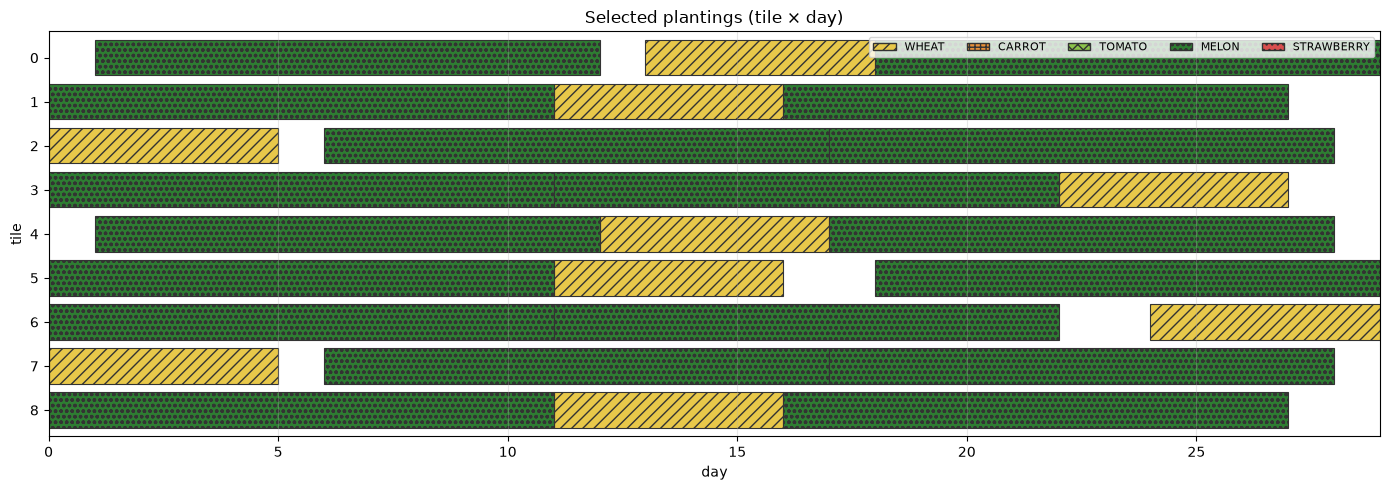

In [12]:
# Quick Gantt chart by CursorAI :)
# Original crop hues + hatches (o is a valid matplotlib hatch)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

CROP_STYLE = {
    "WHEAT":      {"color": "#e8c84a", "hatch": "///"},  # yellow
    "CARROT":     {"color": "#e8913a", "hatch": "+++"},  # orange
    "TOMATO":     {"color": "#8bc34a", "hatch": "xxx"},  # light green
    "MELON":      {"color": "#2e7d32", "hatch": "ooo"},  # dark green
    "STRAWBERRY": {"color": "#d94f4f", "hatch": "..."},  # red
}

fig, ax = plt.subplots(figsize=(14, 5))
for s in selected:
    days = sorted(d for _, d in s["subset"])
    start, end = days[0], days[-1] + 1
    style = CROP_STYLE.get(s["crop"], {"color": "#999999", "hatch": ""})
    ax.barh(
        y=s["tile"],
        width=end - start,
        left=start,
        height=0.8,
        color=style["color"],
        hatch=style["hatch"],
        edgecolor="#333333",
        linewidth=0.8,
    )

ax.set_xlabel("day")
ax.set_ylabel("tile")
ax.set_yticks(range(NUM_TILES))
ax.set_xlim(0, NUM_DAYS)
ax.set_ylim(-0.6, NUM_TILES - 0.4)
ax.set_title("Selected plantings (tile × day)")
ax.invert_yaxis()
ax.legend(
    handles=[
        Patch(facecolor=st["color"], hatch=st["hatch"], edgecolor="#333333", label=name)
        for name, st in CROP_STYLE.items()
    ],
    loc="upper right",
    ncol=len(CROP_STYLE),
    fontsize=8,
)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
